In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from COMPAS.compas_python_utils.detailed_evolution_plotter import plot_detailed_evolution as det_evo
import tempfile

import h5py as h5 
from astropy import units as u
from astropy import constants as c

import os
import scipy

pd.options.display.max_columns = None

In [2]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib
from matplotlib.ticker import LogLocator, AutoMinorLocator, MultipleLocator
# rcParams['font.family'] = 'serif'
# rcParams["mathtext.fontset"] = 'stix'
# rcParams["font.size"] = 18
fontparams = {
    "font.family": "serif",
    "mathtext.fontset" : "stix",
    "grid.color": "gray",
    "grid.linestyle": ":",
    "axes.titlesize": "18",
    "axes.labelsize": "12",
    "xtick.labelsize": "10",
    "ytick.labelsize": "10",
    "xtick.labelbottom": "True",
    "legend.framealpha": "1",
}
rcParams.update(fontparams) 

%config InlineBackend.figure_format='retina' # very useful command for high-res images


In [3]:
from cycler import cycler

colorPalette = {'red': "#E64D4E",
                'orange': "#EE9063",
                'yellow': "#FFDD7B",
                'green': "#77AC54",
                'blue': "#0B92B1",
                'violet': "#665191",
                'gray': "#B4B4B4"
}

custom_cycler = (cycler(color=[colorPalette['red'], colorPalette['blue'], colorPalette['green']]))
color_list = [colorPalette['red'], colorPalette['blue'], colorPalette['green']]

st_labels = ['MS_LT_0.7', 'MS_GT_0.7', 'HG', 'FGB', 'CHeB', 'EAGB', 'TPAGB', 'HeMS', 'HeHG', 'HeGB', 'HeWD', 'COWD', 'ONeWD', 'NS', 'BH', 'MR','CHE',  '--', '--', 'None']


In [89]:
columns_to_keep = ['Time', 'Mass(1)', 'Mass(2)', 'Radius(1)', 'Radius(2)', 'SemiMajorAxis', 'Eccentricity', 'Stellar_Type(1)', 'Stellar_Type(2)', 'Period(1)', 'Period(2)', 'Period_Orb', 'dmMT(1)', 'dmMT(2)', 'Omega(1)', 'Omega(2)', 'Omega_Orb', 'Record_Type']
columns_to_keep_sanity = ['Time', 'M1', 'M2', 'R1', 'R2', 'SemiMajorAxis_Rsun', 'ecc', 'StellarType_1', 'StellarType_2', 'Period1', 'Period2', 'Period_orb', 'dM1_MT', 'dM2_MT']


1. INITIAL_STATE
    Record describes the initial state of the binary

2. POST_STELLAR_TIMESTEP
    Record was logged immediately following stellar timestep (i.e. the evolution of the constituent stars for a single timestep)

3.  POST_BINARY_TIMESTEP
    Record was logged immediately following binary timestep (i.e. the evolution of the binary system for a single timestep)

4.  TIMESTEP_COMPLETED
    Record was logged immediately following the completion of the timestep (after all changes to the binary and components)

5.  FINAL_STATE
    Record describes the final state of the binary

6.  STELLAR_TYPE_CHANGE_DURING_CEE
    Record was logged immediately following a stellar type change during a common envelope event

7.  STELLAR_TYPE_CHANGE_DURING_MT
    Record was logged immediately following a stellar type change during a mass transfer event

8.  STELLAR_TYPE_CHANGE_DURING_MASS_RESOLUTION
    Record was logged immediately following a stellar type change during mass resolution

9.  STELLAR_TYPE_CHANGE_DURING_CHE_EQUILIBRATION
    Record was logged immediately following a stellar type change during mass equilibration for CHE

10.  POST_MT
    Record was logged immediately following a mass transfer event

11.  POST_WINDS
    Record was logged immediately following winds mass loss

12.  POST_CEE
    Record was logged immediately following a common envelope event

13.  POST_SN
    Record was logged immediately following a supernova event

14.  POST_MASS_RESOLUTION
    Record was logged immediately following mass resolution (i.e. after winds mass loss & mass transfer complete)

15.  POST_MASS_RESOLUTION_MERGER
    Record was logged immediately following a merger after mass resolution

16.  PRE_STELLAR_TIMESTEP
    Record was logged immediately prior to stellar timestep (i.e. the evolution of the constituent stars for a single timestep)


# SMT BBH that stays spinning with Tides

In [ ]:
# notides_DataPath = 'sim_data/smt_notides'
tides_DataPath = 'sim_data/smt_realistic'
perfect_DataPath = 'sim_data/smt_perfect'

# # --------------

# df_detailed_notides = pd.read_csv(notides_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0)
# df_detailed_notides = df_detailed_notides.rename(columns=lambda x: x.strip())

df_detailed_tides = pd.read_csv(tides_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0)
df_detailed_tides = df_detailed_tides.rename(columns=lambda x: x.strip())

df_detailed_perfect = pd.read_csv(perfect_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0)
df_detailed_perfect = df_detailed_perfect.rename(columns=lambda x: x.strip())



# df_dco_notides = pd.read_csv(notides_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
# df_dco_notides = df_dco_notides.rename(columns=lambda x: x.strip())

df_dco_tides = pd.read_csv(tides_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
df_dco_tides = df_dco_tides.rename(columns=lambda x: x.strip())

df_dco_perfect = pd.read_csv(perfect_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
df_dco_perfect = df_dco_perfect.rename(columns=lambda x: x.strip())


### Realistic Tides

Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000043   Zero-age main-sequence, metallicity Z=0.0003   55.238     1     52.096     1    139.948  0.634
  4.122752   Stable mass transfer from 1 to 2   52.705     1     50.271     1     53.140  0.000
  4.450018   Star 1: MS->HG                    32.624     2     70.265     1     55.901  0.000
  4.451633   Stable mass transfer from 1 to 2   19.240     7     83.646     1    104.462  0.000
  4.451633   Star 1: HG->HeMS                  19.240     7     83.646     1    104.462  0.000
  4.886338   Star 1: HeMS->HeHG                19.124     8     82.663     1    108.812  0.000
  4.887786   Star 1 undergoes supernova and forms a BH   19.124    14     82.659     1    108.828  0.000
  5.874620   Star 2: MS->HG                    19.124    14     79.156     2    121.958  0.000
  5.875254   Stable mass transfer from 2 to 1   19.124    14     33.599     7     10.763  0.000
  5.875254   Star 2: HG->H

(<Figure size 900x480 with 7 Axes>,
  <COMPAS.compas_python_utils.detailed_evolution_plotter.plot_detailed_evolution.Event at 0x173050310>])

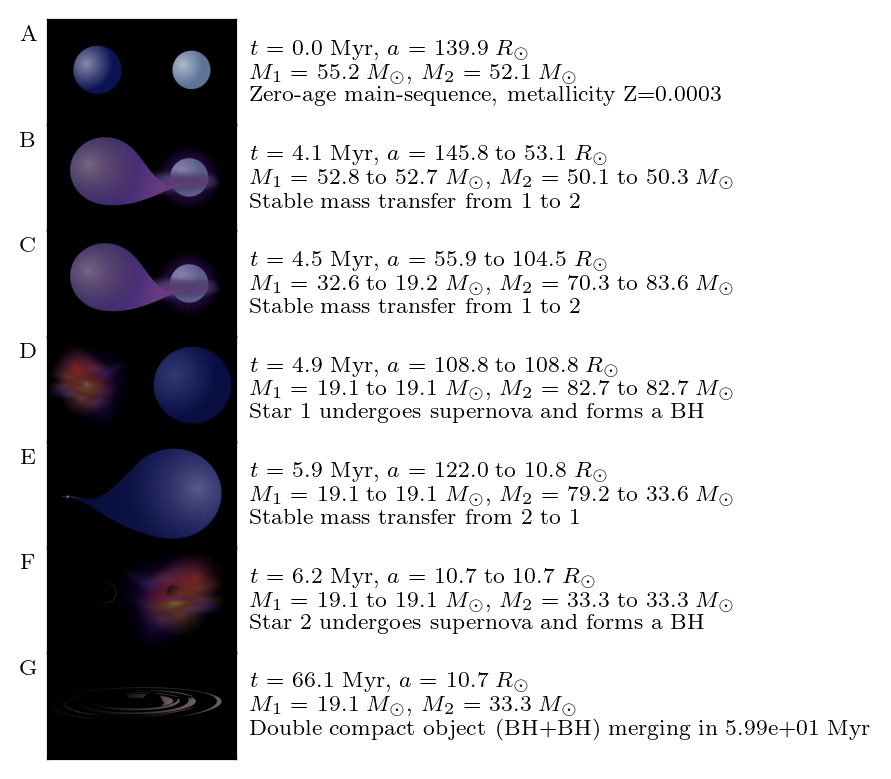

In [99]:
RawData = df_detailed_tides
tf = tempfile.TemporaryFile()
Data = h5.File(tf, 'w')
maskRecordType4 = RawData['Record_Type'] == 4     # Filter first for only end-of-timestep events
for key in RawData.keys():
    Data.create_dataset(key, data=RawData[key][maskRecordType4])

### Collect the important events in the detailed evolution
events = det_evo.allEvents(Data).allEvents                 # Calculate the events here, for use in plot sizing parameters
det_evo.printEvolutionaryHistory(events=events)
# det_evo.makeDetailedPlots(Data, events, outdir=None, show=True)
print("Merges Hubble Time?:", df_dco_tides['Merges_Hubble_Time'].values.astype(bool))
det_evo.plotVanDenHeuvel(events, outdir=None, use_latex=True)

In [117]:
df_detailed_tides['Period(1)'] = (2 * np.pi / (df_detailed_tides['Omega(1)'].values / u.s)).to(u.day)
df_detailed_tides['Period(2)'] = (2 * np.pi / (df_detailed_tides['Omega(2)'].values / u.s)).to(u.day)

omega_orb = np.sqrt(c.G * (df_detailed_tides['Mass(1)'].values * u.M_sun + df_detailed_tides['Mass(2)'].values * u.M_sun) / (df_detailed_tides['SemiMajorAxis'].values*u.AU)**3).to(1/u.s)
df_detailed_tides['Omega_Orb'] = omega_orb.value
df_detailed_tides['Period_Orb'] = (2 * np.pi / omega_orb).to(u.day)

df_detailed_tides_short = df_detailed_tides[columns_to_keep]

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [123]:
# st_change_idx = np.where((df_detailed_tides['Stellar_Type(1)'] != df_detailed_tides['Stellar_Type(1)'].shift()) | (df_detailed_tides['Stellar_Type(2)'] != df_detailed_tides['Stellar_Type(2)'].shift()))[0]
# st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx+1])
# st_changes_with_buffer.sort()
# df_detailed_tides_short.iloc[st_changes_with_buffer] # the +1 is to get the row after the change, which is after tidal effects

In [119]:
df_dco_tides

,SEED,SemiMajorAxis@DCO,Eccentricity@DCO,Mass(1),Stellar_Type(1),Mass(2),Stellar_Type(2),Coalescence_Time,Time,Merges_Hubble_Time,Recycled_NS(1),Recycled_NS(2),Record_Type
0,1063,0.049969,0.0,19.124019,14,33.321738,14,59.977399,6.198458,1,0,0,1


In [120]:
df_sanity_tides = pd.read_csv(tides_DataPath+'/sanity_checks.csv', header=0)
df_sanity_tides = df_sanity_tides.rename(columns=lambda x: x.strip())

In [121]:
df_sanity_tides['SemiMajorAxis_Rsun'] = (df_sanity_tides['SemiMajorAxis_after'].values * u.AU).to(u.R_sun)
df_sanity_tides['Period1'] = (2 * np.pi / (df_sanity_tides['Omega1'].values / u.yr)).to(u.day)
df_sanity_tides['Period2'] = (2 * np.pi / (df_sanity_tides['Omega2'].values / u.yr)).to(u.day)
df_sanity_tides['Period_orb'] = (2 * np.pi / (df_sanity_tides['Omega'].values / u.yr)).to(u.day)


df_sanity_tides_short = df_sanity_tides[columns_to_keep_sanity]

In [122]:
st_change_idx = np.where((df_sanity_tides_short['StellarType_1'] != df_sanity_tides_short['StellarType_1'].shift()) | (df_sanity_tides_short['StellarType_2'] != df_sanity_tides_short['StellarType_2'].shift()))[0]
st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx-1])
st_changes_with_buffer.sort()
df_sanity_tides_short.iloc[st_changes_with_buffer][1:]

,Time,M1,M2,R1,R2,SemiMajorAxis_Rsun,ecc,StellarType_1,StellarType_2,Period1,Period2,Period_orb,dM1_MT,dM2_MT
0,0.00000,32.9017,28.4904,6.264330,5.753160,87.420248,5.707070e-02,1,1,6.743101e+06,8.383717e+06,12.083621,0.00000,0.0000
1430,6.19234,31.4757,27.7219,15.907100,12.331600,90.653471,5.702470e-02,1,1,3.626284e+03,2.597865e+03,12.994504,0.00000,0.0000
1431,6.19234,31.4755,27.7218,15.583600,12.331500,90.653901,5.702470e-02,2,1,2.368543e+03,2.597901e+03,12.994652,0.00000,0.0000
2081,6.19502,31.4748,27.7213,33.336000,12.343800,90.655837,5.702470e-02,2,1,1.077540e+04,2.603335e+03,12.995167,0.00000,0.0000
2082,6.19502,10.2024,48.9937,0.948326,10.239200,208.816651,0.000000e+00,7,1,1.078466e+04,5.422055e-01,45.429293,-21.27240,21.2724
2300,6.83388,10.0924,48.3953,0.942019,11.656900,215.275142,0.000000e+00,7,1,1.131579e+04,7.534871e-01,47.840017,0.00000,0.0000
2301,6.83388,10.0919,48.3931,0.942011,11.656600,215.298796,0.000000e+00,8,1,3.562051e+03,7.536455e-01,47.849393,0.00000,0.0000
2423,6.86139,10.0846,48.3660,1.071920,11.734900,215.599841,0.000000e+00,8,1,3.896017e+03,7.662319e-01,47.963497,0.00000,0.0000
2424,6.86155,10.0846,48.3658,0.000043,11.735300,215.599841,2.220450e-16,14,1,9.487509e-05,7.663035e-01,47.964099,0.00000,0.0000
3593,8.54158,10.0846,46.1344,0.000043,21.629000,237.419153,2.220450e-16,14,1,9.487509e-05,3.402154e+00,56.515153,0.00000,0.0000


### Perfect Tides

Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000061   Zero-age main-sequence, metallicity Z=0.0020   32.902     1     28.490     1     86.798  0.000
  6.192338   Star 1: MS->HG                    31.476     2     27.722     1     88.521  0.000
  6.195038   Stable mass transfer from 1 to 2   10.203     7     48.993     1    263.315  0.000
  6.195038   Star 1: HG->HeMS                  10.203     7     48.993     1    263.315  0.000
  6.833881   Star 1: HeMS->HeHG                10.093     8     48.395     1    266.386  0.000
  6.861699   Star 1 undergoes supernova and forms a BH   10.085    14     48.365     1    266.550  0.000
  8.541586   Star 2: MS->HG                    10.085    14     46.134     2    275.869  0.000
  8.543937   Stable mass transfer from 2 to 1   10.085    14     17.151     7     11.021  0.000
  8.543937   Star 2: HG->HeMS                  10.085    14     17.151     7     11.021  0.000
  9.008894   Star 2: HeMS->

(<Figure size 900x480 with 6 Axes>,
  <COMPAS.compas_python_utils.detailed_evolution_plotter.plot_detailed_evolution.Event at 0x16f272290>])

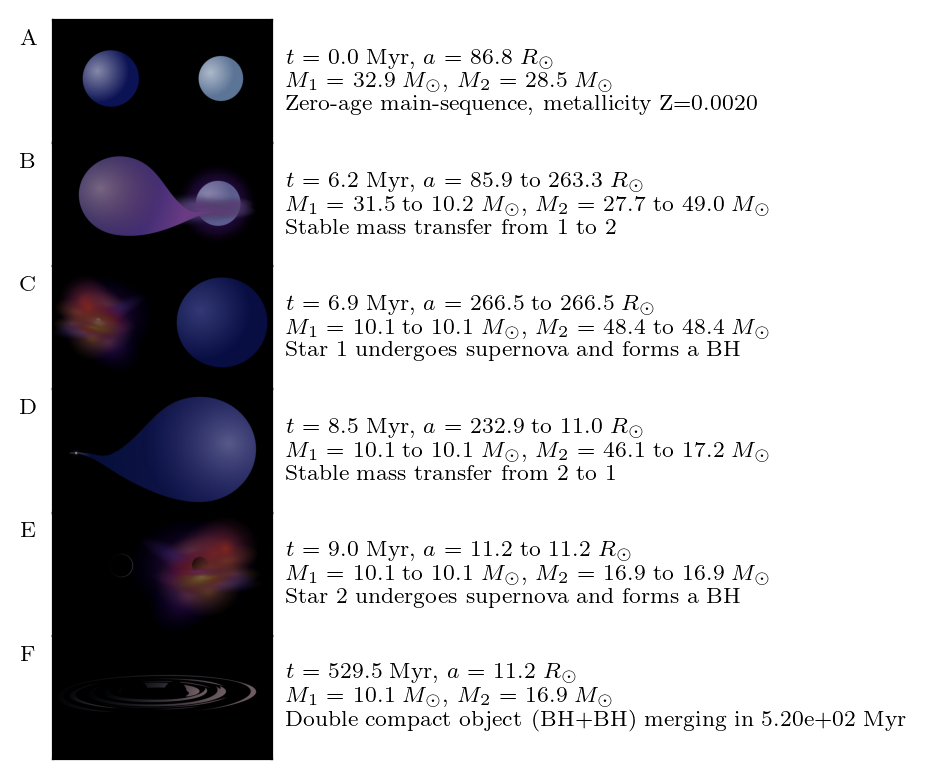

In [9]:
RawData = df_detailed_perfect
tf = tempfile.TemporaryFile()
Data = h5.File(tf, 'w')
maskRecordType4 = RawData['Record_Type'] == 4     # Filter first for only end-of-timestep events
for key in RawData.keys():
    Data.create_dataset(key, data=RawData[key][maskRecordType4])

### Collect the important events in the detailed evolution
events = det_evo.allEvents(Data).allEvents                 # Calculate the events here, for use in plot sizing parameters
det_evo.printEvolutionaryHistory(events=events)
# det_evo.makeDetailedPlots(Data, events, outdir=None, show=True)
# print("Merges Hubble Time?:", df_dco_perfect['Merges_Hubble_Time'].values.astype(bool))
det_evo.plotVanDenHeuvel(events, outdir=None, use_latex=True)

In [59]:
df_detailed_perfect['Period(1)'] = (2 * np.pi / (df_detailed_perfect['Omega(1)'].values / u.s)).to(u.day)
df_detailed_perfect['Period(2)'] = (2 * np.pi / (df_detailed_perfect['Omega(2)'].values / u.s)).to(u.day)

omega_orb = np.sqrt(c.G * (df_detailed_perfect['Mass(1)'].values * u.M_sun + df_detailed_perfect['Mass(2)'].values * u.M_sun) / (df_detailed_perfect['SemiMajorAxis'].values*u.AU)**3).to(1/u.s)
df_detailed_perfect['Omega_Orb'] = omega_orb.value
df_detailed_perfect['Period_Orb'] = (2 * np.pi / omega_orb).to(u.day)

df_detailed_perfect_short = df_detailed_perfect[columns_to_keep]

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [124]:
# st_change_idx = np.where((df_detailed_perfect_short['Stellar_Type(1)'] != df_detailed_perfect_short['Stellar_Type(1)'].shift()) | (df_detailed_perfect_short['Stellar_Type(2)'] != df_detailed_perfect_short['Stellar_Type(2)'].shift()))[0]
# st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx+1])
# st_changes_with_buffer.sort()
# df_detailed_perfect_short.iloc[st_changes_with_buffer]


In [10]:
df_dco_perfect

,SEED,SemiMajorAxis@DCO,Eccentricity@DCO,Mass(1),Stellar_Type(1),Mass(2),Stellar_Type(2),Coalescence_Time,Time,Merges_Hubble_Time,Recycled_NS(1),Recycled_NS(2),Record_Type
0,902,0.052202,0.0,10.085159,14,16.860128,14,521.104525,9.012482,1,0,0,1


In [114]:
df_sanity_perfect = pd.read_csv(perfect_DataPath+'/sanity_checks.csv', header=0)
df_sanity_perfect = df_sanity_perfect.rename(columns=lambda x: x.strip())

In [115]:
df_sanity_perfect['SemiMajorAxis_Rsun'] = (df_sanity_perfect['SemiMajorAxis_after'].values * u.AU).to(u.R_sun)
df_sanity_perfect['Period1'] = (2 * np.pi / (df_sanity_perfect['Omega1'].values / u.yr)).to(u.day)
df_sanity_perfect['Period2'] = (2 * np.pi / (df_sanity_perfect['Omega2'].values / u.yr)).to(u.day)
df_sanity_perfect['Period_orb'] = (2 * np.pi / (df_sanity_perfect['Omega'].values / u.yr)).to(u.day)


df_sanity_perfect_short = df_sanity_perfect[columns_to_keep_sanity]

In [116]:
st_change_idx = np.where((df_sanity_perfect_short['StellarType_1'] != df_sanity_perfect_short['StellarType_1'].shift()) | (df_sanity_perfect_short['StellarType_2'] != df_sanity_perfect_short['StellarType_2'].shift()))[0]
st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx-1])
st_changes_with_buffer.sort()
df_sanity_perfect_short.iloc[st_changes_with_buffer][1:]


,Time,M1,M2,R1,R2,SemiMajorAxis_Rsun,ecc,StellarType_1,StellarType_2,Period1,Period2,Period_orb,dM1_MT,dM2_MT
0,0.00000,32.9017,28.4904,6.264330,5.753160,86.798160,0,1,1,11.954833,11.954833,11.954833,0.000000,0.0000
1430,6.19234,31.4757,27.7219,15.907100,12.331600,88.521212,0,1,1,12.538701,12.538701,12.538701,0.000000,0.0000
1431,6.19234,31.4755,27.7218,15.583600,12.331500,88.956222,0,2,1,12.631317,12.631317,12.631317,0.000000,0.0000
2085,6.19503,31.4747,27.7213,33.486300,12.343900,85.905131,0,2,1,11.987179,11.987179,11.987179,0.000000,0.0000
2086,6.19504,10.2028,48.9933,0.948349,10.239200,263.315476,0,7,1,64.328177,64.328177,64.328177,-21.272000,21.2720
2304,6.83388,10.0928,48.3949,0.942042,11.656900,266.386135,0,7,1,65.852126,65.852126,65.852126,0.000000,0.0000
2305,6.83388,10.0923,48.3927,0.942034,11.656500,266.399037,0,8,1,65.858552,65.858552,65.858552,0.000000,0.0000
2427,6.86139,10.0850,48.3656,1.071950,11.734800,266.549560,0,8,1,65.933290,65.933290,65.933290,0.000000,0.0000
2428,6.86155,10.0850,48.3654,0.000043,11.735300,266.549560,0,14,1,65.933858,65.933858,65.933858,0.000000,0.0000
3597,8.54159,10.0850,46.1341,0.000043,21.628900,275.869053,0,14,1,70.786273,70.786273,70.786273,0.000000,0.0000


# CE binary not able to spin up

In [152]:
notides_DataPath = 'sim_data/ce_notides'
tides_DataPath = 'sim_data/ce_realistic'
perfect_DataPath = 'sim_data/ce_perfect'

# # --------------

df_detailed_notides = pd.read_csv(notides_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0)
df_detailed_notides = df_detailed_notides.rename(columns=lambda x: x.strip())

df_detailed_tides = pd.read_csv(tides_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0, low_memory=False)
df_detailed_tides = df_detailed_tides.rename(columns=lambda x: x.strip())

df_detailed_perfect = pd.read_csv(perfect_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0)
df_detailed_perfect = df_detailed_perfect.rename(columns=lambda x: x.strip())



df_dco_notides = pd.read_csv(notides_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
df_dco_notides = df_dco_notides.rename(columns=lambda x: x.strip())

df_dco_tides = pd.read_csv(tides_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
df_dco_tides = df_dco_tides.rename(columns=lambda x: x.strip())

df_dco_perfect = pd.read_csv(perfect_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
df_dco_perfect = df_dco_perfect.rename(columns=lambda x: x.strip())


### Realistic Tides

Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000044   Zero-age main-sequence, metallicity Z=0.0010   54.008     1     27.317     1    812.927  0.198
  4.468930   Star 1: MS->HG                    50.116     2     27.038     1    856.868  0.198
  4.473030   Star 1: HG->CHeB                  19.478     4     27.037     1   1421.255  0.198
  4.490653   Star 1: CHeB->HeMS                19.469     7     27.036     1   1421.608  0.198
  4.906083   Star 1: HeMS->HeHG                19.237     8     26.991     1   1430.100  0.198
  4.907528   Star 1 undergoes supernova and forms a BH   19.237    14     26.991     1   1430.136  0.198
  7.259309   Star 2: MS->HG                    19.237    14     26.658     2   1440.497  0.198
  7.269718   Star 2: HG->CHeB                  19.237    14     26.656     4   1440.570  0.198
  7.748146   Common envelope initiated by 2    19.237    14      9.831     7      8.992  0.000
  7.748146   Star 2: CHeB->He

(<Figure size 900x480 with 5 Axes>,
  <COMPAS.compas_python_utils.detailed_evolution_plotter.plot_detailed_evolution.Event at 0x173eb7410>])

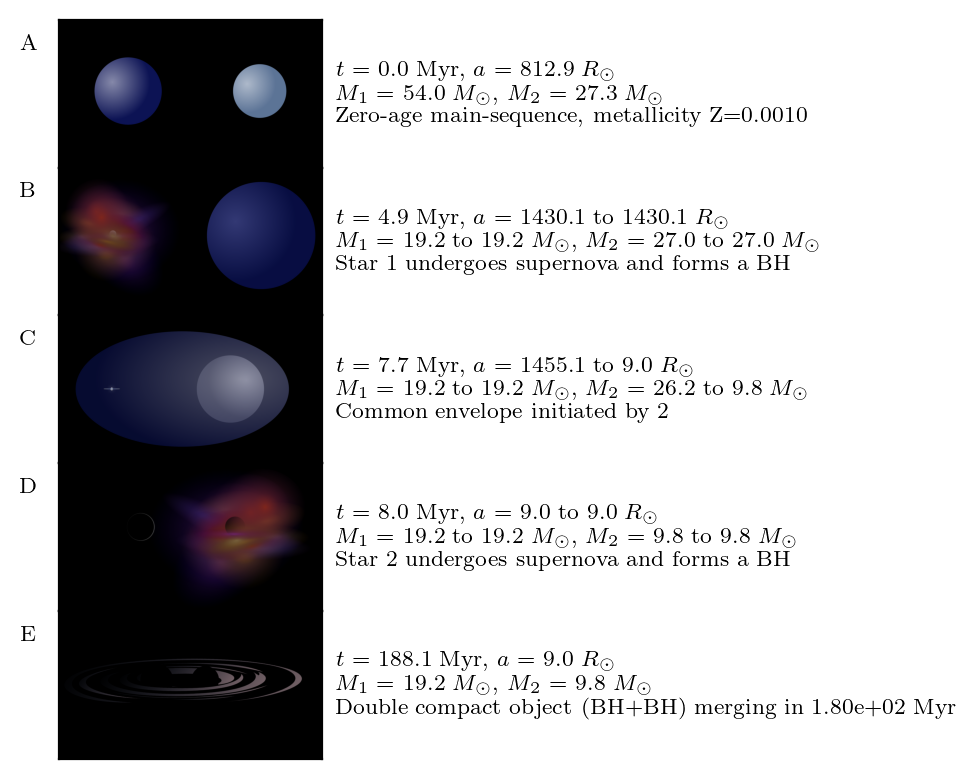

In [136]:
RawData = df_detailed_tides
tf = tempfile.TemporaryFile()
Data = h5.File(tf, 'w')
maskRecordType4 = RawData['Record_Type'] == 4     # Filter first for only end-of-timestep events
for key in RawData.keys():
    Data.create_dataset(key, data=RawData[key][maskRecordType4])

### Collect the important events in the detailed evolution
events = det_evo.allEvents(Data).allEvents                 # Calculate the events here, for use in plot sizing parameters
det_evo.printEvolutionaryHistory(events=events)
# det_evo.makeDetailedPlots(Data, events, outdir=None, show=True)
print("Merges Hubble Time?:", df_dco_tides['Merges_Hubble_Time'].values.astype(bool))
det_evo.plotVanDenHeuvel(events, outdir=None, use_latex=True)

In [146]:
df_sanity_tides = pd.read_csv(tides_DataPath+'/sanity_checks.csv', header=0)
df_sanity_tides = df_sanity_tides.rename(columns=lambda x: x.strip())

df_sanity_tides['SemiMajorAxis_Rsun'] = (df_sanity_tides['SemiMajorAxis_after'].values * u.AU).to(u.R_sun)
df_sanity_tides['Period1'] = (2 * np.pi / (df_sanity_tides['Omega1'].values / u.yr)).to(u.day)
df_sanity_tides['Period2'] = (2 * np.pi / (df_sanity_tides['Omega2'].values / u.yr)).to(u.day)
df_sanity_tides['Period_orb'] = (2 * np.pi / (df_sanity_tides['Omega'].values / u.yr)).to(u.day)

df_sanity_tides_short = df_sanity_tides[columns_to_keep_sanity]

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [139]:
st_change_idx = np.where((df_sanity_tides_short['StellarType_1'] != df_sanity_tides_short['StellarType_1'].shift()) | (df_sanity_tides_short['StellarType_2'] != df_sanity_tides_short['StellarType_2'].shift()))[0]
st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx-1])
st_changes_with_buffer.sort()
df_sanity_tides_short.iloc[st_changes_with_buffer][1:]

,Time,M1,M2,R1,R2,SemiMajorAxis_Rsun,ecc,StellarType_1,StellarType_2,Period1,Period2,Period_orb,dM1_MT,dM2_MT
0,0.00000,54.0076,27.31660,7.893920,5.371600,812.926914,1.976280e-01,1,1,inf,inf,297.716202,0,0.0000
1520,4.46893,50.1161,27.03780,20.607000,7.586000,856.868735,1.976280e-01,1,1,1.493728e+12,4.994654e+11,330.770701,0,0.0000
1521,4.46893,50.1156,27.03780,20.013300,7.586000,856.873036,1.976280e-01,2,1,8.804318e+11,4.994273e+11,330.774992,0,0.0000
4383,4.47303,19.4783,27.03740,28.776000,7.590020,1421.255033,1.976280e-01,2,1,1.986629e+20,3.333290e+11,910.005366,0,0.0000
4384,4.47303,19.4743,27.03730,6.542040,7.590010,1421.379752,1.976280e-01,4,1,2.109508e+19,3.333266e+11,910.164165,0,0.0000
5686,4.48976,19.4686,27.03560,1.414030,7.606490,1421.607686,1.976280e-01,4,1,1.318889e+18,3.347551e+11,910.456643,0,0.0000
5687,4.49065,19.4653,27.03480,1.414270,7.607250,1421.732404,1.976280e-01,7,1,4.730534e+17,3.348132e+11,910.615599,0,0.0000
5817,4.90608,19.2369,26.99110,1.397710,8.062690,1430.099305,1.976280e-01,7,1,2.023626e+17,3.754947e+11,921.367692,0,0.0000
5818,4.90608,19.2369,26.99100,0.000082,8.062660,1430.135861,1.976280e-01,14,1,2.760254e+09,3.754898e+11,921.400985,0,0.0000
6744,7.25931,19.2369,26.65850,0.000082,13.150000,1440.496110,1.976280e-01,14,1,2.541322e+09,9.865250e+11,934.799769,0,0.0000


### Perfect Tides

Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000044   Zero-age main-sequence, metallicity Z=0.0010   54.008     1     27.317     1    781.118  0.000
  4.468930   Star 1: MS->HG                    50.116     2     27.038     1    823.091  0.000
  4.473030   Star 1: HG->CHeB                  19.478     4     27.037     1   1369.640  0.000
  4.490653   Star 1: CHeB->HeMS                19.469     7     27.036     1   1369.980  0.000
  4.906083   Star 1: HeMS->HeHG                19.237     8     26.991     1   1378.163  0.000
  4.907528   Star 1 undergoes supernova and forms a BH   19.237    14     26.991     1   1378.198  0.000
  7.259309   Star 2: MS->HG                    19.237    14     26.658     2   1388.145  0.000
  7.269718   Star 2: HG->CHeB                  19.237    14     26.656     4   1387.610  0.000
  7.757619   Common envelope initiated by 2    19.237    14      9.862     7     10.325  0.000
  7.757619   Star 2: CHeB->He

(<Figure size 900x480 with 5 Axes>,
  <COMPAS.compas_python_utils.detailed_evolution_plotter.plot_detailed_evolution.Event at 0x1740fe150>])

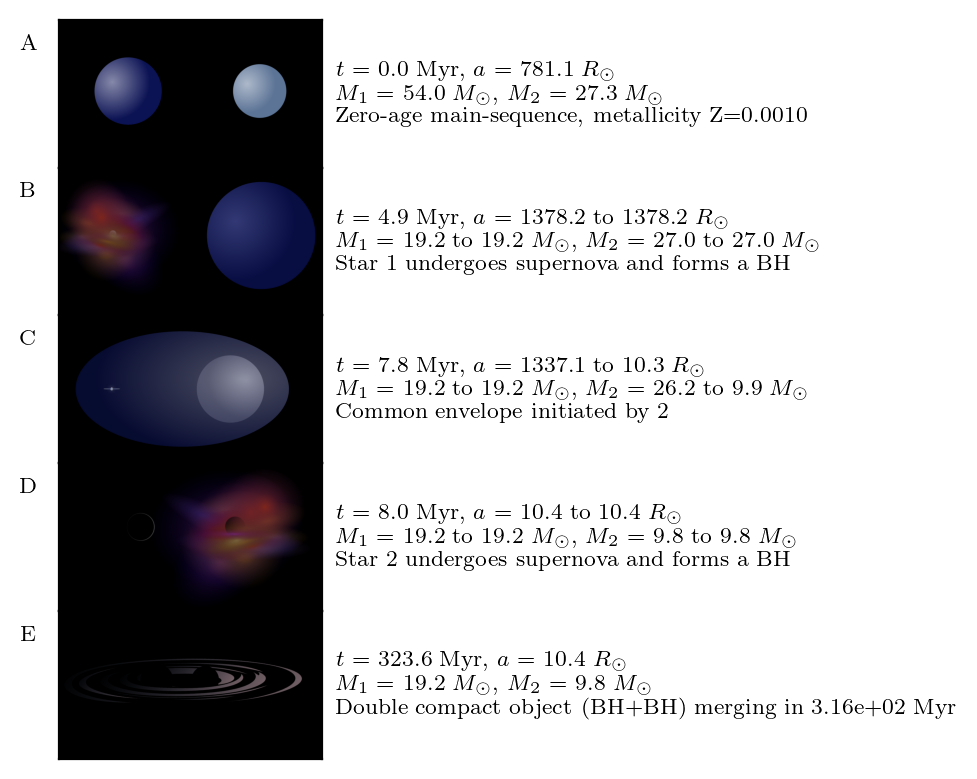

In [143]:
RawData = df_detailed_perfect
tf = tempfile.TemporaryFile()
Data = h5.File(tf, 'w')
maskRecordType4 = RawData['Record_Type'] == 4     # Filter first for only end-of-timestep events
for key in RawData.keys():
    Data.create_dataset(key, data=RawData[key][maskRecordType4])

### Collect the important events in the detailed evolution
events = det_evo.allEvents(Data).allEvents                 # Calculate the events here, for use in plot sizing parameters
det_evo.printEvolutionaryHistory(events=events)
# det_evo.makeDetailedPlots(Data, events, outdir=None, show=True)
# print("Merges Hubble Time?:", df_dco_perfect['Merges_Hubble_Time'].values.astype(bool))
det_evo.plotVanDenHeuvel(events, outdir=None, use_latex=True)

In [144]:
df_sanity_perfect = pd.read_csv(perfect_DataPath+'/sanity_checks.csv', header=0)
df_sanity_perfect = df_sanity_perfect.rename(columns=lambda x: x.strip())

df_sanity_perfect['SemiMajorAxis_Rsun'] = (df_sanity_perfect['SemiMajorAxis_after'].values * u.AU).to(u.R_sun)
df_sanity_perfect['Period1'] = (2 * np.pi / (df_sanity_perfect['Omega1'].values / u.yr)).to(u.day)
df_sanity_perfect['Period2'] = (2 * np.pi / (df_sanity_perfect['Omega2'].values / u.yr)).to(u.day)
df_sanity_perfect['Period_orb'] = (2 * np.pi / (df_sanity_perfect['Omega'].values / u.yr)).to(u.day)

df_sanity_perfect_short = df_sanity_perfect[columns_to_keep_sanity]

In [145]:
st_change_idx = np.where((df_sanity_perfect_short['StellarType_1'] != df_sanity_perfect_short['StellarType_1'].shift()) | (df_sanity_perfect_short['StellarType_2'] != df_sanity_perfect_short['StellarType_2'].shift()))[0]
st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx-1])
st_changes_with_buffer.sort()
df_sanity_perfect_short.iloc[st_changes_with_buffer][1:]

,Time,M1,M2,R1,R2,SemiMajorAxis_Rsun,ecc,StellarType_1,StellarType_2,Period1,Period2,Period_orb,dM1_MT,dM2_MT
0,0.00000,54.0076,27.31660,7.893920,5.371600,781.117207,0,1,1,280.414345,280.414345,280.414345,0,0.0000
1520,4.46893,50.1161,27.03780,20.607000,7.586000,823.091484,0,1,1,311.406694,311.406694,311.406694,0,0.0000
1521,4.46893,50.1156,27.03780,20.013300,7.586000,823.216203,0,2,1,311.478969,311.478969,311.478969,0,0.0000
4383,4.47303,19.4783,27.03740,28.776000,7.590020,1369.638714,0,2,1,860.883053,860.883053,860.883053,0,0.0000
4384,4.47303,19.4743,27.03730,6.542040,7.590010,1369.761283,0,4,1,861.034860,861.034860,861.034860,0,0.0000
5686,4.48976,19.4686,27.03560,1.414030,7.606490,1369.980615,0,4,1,861.312774,861.312774,861.312774,0,0.0000
5687,4.49065,19.4653,27.03480,1.414270,7.607250,1370.101033,0,7,1,861.464733,861.464733,861.464733,0,0.0000
5817,4.90608,19.2369,26.99110,1.397710,8.062690,1378.162589,0,7,1,871.633832,871.633832,871.633832,0,0.0000
5818,4.90608,19.2369,26.99100,0.000082,8.062660,1378.196994,0,14,1,871.666939,871.666939,871.666939,0,0.0000
6744,7.25931,19.2369,26.65850,0.000082,13.150000,1388.144382,0,14,1,884.306073,884.306073,884.306073,0,0.0000


### Notides

Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000044   Zero-age main-sequence, metallicity Z=0.0010   54.008     1     27.317     1    812.927  0.198
  4.468930   Star 1: MS->HG                    50.116     2     27.038     1    856.868  0.198
  4.473030   Star 1: HG->CHeB                  19.478     4     27.037     1   1421.255  0.198
  4.490653   Star 1: CHeB->HeMS                19.469     7     27.036     1   1421.608  0.198
  4.906083   Star 1: HeMS->HeHG                19.237     8     26.991     1   1430.100  0.198
  4.907528   Star 1 undergoes supernova and forms a BH   19.237    14     26.991     1   1430.136  0.198
  7.259309   Star 2: MS->HG                    19.237    14     26.658     2   1440.497  0.198
  7.269718   Star 2: HG->CHeB                  19.237    14     26.656     4   1440.570  0.198
  7.748146   Common envelope initiated by 2    19.237    14      9.831     7      8.992  0.000
  7.748146   Star 2: CHeB->He

(<Figure size 900x480 with 5 Axes>,
  <COMPAS.compas_python_utils.detailed_evolution_plotter.plot_detailed_evolution.Event at 0x1743c9d50>])

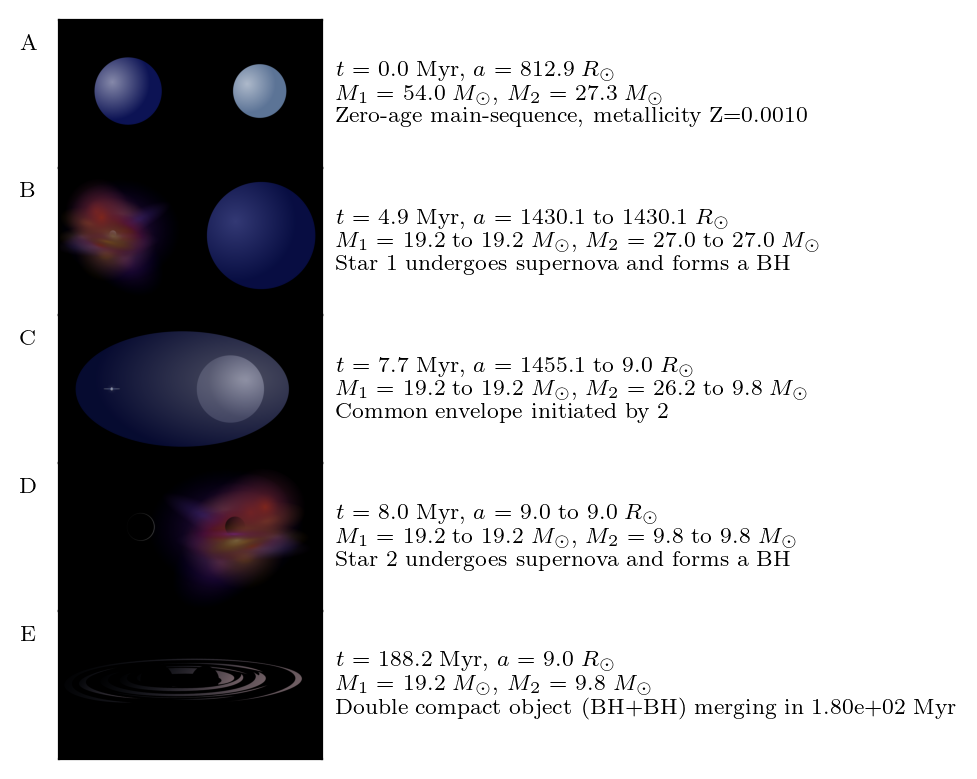

In [147]:
RawData = df_detailed_notides
tf = tempfile.TemporaryFile()
Data = h5.File(tf, 'w')
maskRecordType4 = RawData['Record_Type'] == 4     # Filter first for only end-of-timestep events
for key in RawData.keys():
    Data.create_dataset(key, data=RawData[key][maskRecordType4])

### Collect the important events in the detailed evolution
events = det_evo.allEvents(Data).allEvents                 # Calculate the events here, for use in plot sizing parameters
det_evo.printEvolutionaryHistory(events=events)
# det_evo.makeDetailedPlots(Data, events, outdir=None, show=True)
print("Merges Hubble Time?:", df_dco_tides['Merges_Hubble_Time'].values.astype(bool))
det_evo.plotVanDenHeuvel(events, outdir=None, use_latex=True)

In [150]:
df_sanity_notides = pd.read_csv(notides_DataPath+'/sanity_checks.csv', header=0)
df_sanity_notides = df_sanity_notides.rename(columns=lambda x: x.strip())

df_sanity_notides['SemiMajorAxis_Rsun'] = (df_sanity_notides['SemiMajorAxis_after'].values * u.AU).to(u.R_sun)
df_sanity_notides['Period1'] = (2 * np.pi / (df_sanity_notides['Omega1'].values / u.yr)).to(u.day)
df_sanity_notides['Period2'] = (2 * np.pi / (df_sanity_notides['Omega2'].values / u.yr)).to(u.day)
df_sanity_notides['Period_orb'] = (2 * np.pi / (df_sanity_notides['Omega'].values / u.yr)).to(u.day)

df_sanity_notides_short = df_sanity_notides[columns_to_keep_sanity]

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [151]:
st_change_idx = np.where((df_sanity_notides_short['StellarType_1'] != df_sanity_notides_short['StellarType_1'].shift()) | (df_sanity_notides_short['StellarType_2'] != df_sanity_notides_short['StellarType_2'].shift()))[0]
st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx-1])
st_changes_with_buffer.sort()
df_sanity_notides_short.iloc[st_changes_with_buffer][1:]

,Time,M1,M2,R1,R2,SemiMajorAxis_Rsun,ecc,StellarType_1,StellarType_2,Period1,Period2,Period_orb,dM1_MT,dM2_MT
0,0.00000,54.0076,27.31660,7.893920,5.371600,812.926914,1.976280e-01,1,1,inf,inf,297.716202,0,0.0000
1520,4.46893,50.1161,27.03780,20.607000,7.586000,856.868735,1.976280e-01,1,1,inf,inf,330.770701,0,0.0000
1521,4.46893,50.1156,27.03780,20.013300,7.586000,856.873036,1.976280e-01,2,1,inf,inf,330.774992,0,0.0000
4383,4.47303,19.4783,27.03740,28.776000,7.590020,1421.255033,1.976280e-01,2,1,inf,inf,910.005366,0,0.0000
4384,4.47303,19.4743,27.03730,6.542040,7.590010,1421.379752,1.976280e-01,4,1,inf,inf,910.164165,0,0.0000
5686,4.48976,19.4686,27.03560,1.414030,7.606490,1421.607686,1.976280e-01,4,1,inf,inf,910.456643,0,0.0000
5687,4.49065,19.4653,27.03480,1.414270,7.607250,1421.732404,1.976280e-01,7,1,inf,inf,910.615599,0,0.0000
5817,4.90608,19.2369,26.99110,1.397710,8.062690,1430.099305,1.976280e-01,7,1,inf,inf,921.367692,0,0.0000
5818,4.90608,19.2369,26.99100,0.000082,8.062660,1430.135861,1.976280e-01,14,1,inf,inf,921.400985,0,0.0000
6744,7.25931,19.2369,26.65850,0.000082,13.150000,1440.496110,1.976280e-01,14,1,inf,inf,934.799769,0,0.0000
